# Regularization: L2 Regularized Regression
(aka Ridge regression aka weight decay)

In this notebook we explore L2 regularization, and the impact it has on reducing the variance of a solution.

We explore how it can control overfitting in 2 examples: a setting where we do not have many points, and a setting where we have near colinearity in the features.

In [ ]:
# Some useful imports...
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
import pandas as pd
from pandas import DataFrame, Series
import seaborn as sns
#from sklearn.cross_validation import train_test_split
from sklearn.model_selection import train_test_split
sns.set(style='ticks', palette='Set2')
%matplotlib inline

Recall that the Ordinary Least Squares (OLS) regression solution for the linear model $y = X\beta + e$, is given by

$$
\arg\min_{\beta}: \,\, \|X \beta - y\|_2^2 = \arg\min_{\beta}{\rm SSE}(\beta)
$$

Regularization adds a penalty. Ridge regression adds a squared penalty which serves to regularize and shrink the coefficients:

$$
\arg\min_{\beta}{\rm SSE}(\beta) + \lambda \sum \beta_i^2 = \arg\min_{\beta}{\rm SSE}(\beta) + \lambda \|\beta\|_2^2
$$

# A first example with a visualization

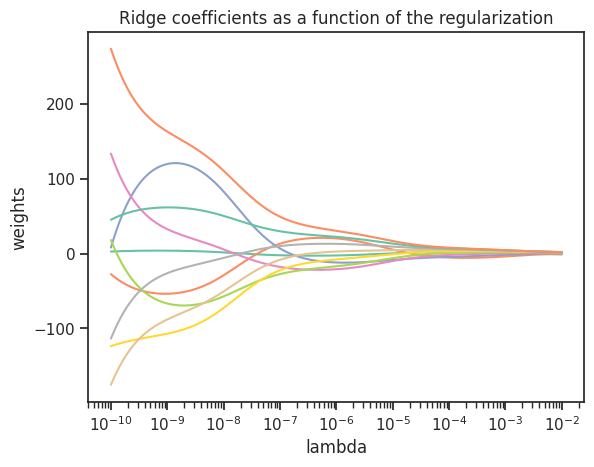

In [ ]:
# A first (stylized) example of what Ridge Regression does

# Author: Fabian Pedregosa -- <fabian.pedregosa@inria.fr>
# License: BSD 3 clause

# We generate the data
# X is the 10x10 Hilbert matrix
X = 1. / (np.arange(1, 11) + np.arange(0, 10)[:, np.newaxis])
y = np.ones(10)

# #############################################################################
# Compute paths

n_alphas = 200
alphas = np.logspace(-10, -2, n_alphas)

coefs = []
for a in alphas:
    ridge = linear_model.Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X, y)
    coefs.append(ridge.coef_)

# #############################################################################
# Display results

ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale('log')
#ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel('lambda')
plt.ylabel('weights')
plt.title('Ridge coefficients as a function of the regularization')
plt.axis('tight')
plt.show()

# A Second Example: Fitting Polynomials

In [ ]:
# Random number generator
rng = np.random.default_rng(13)

[]

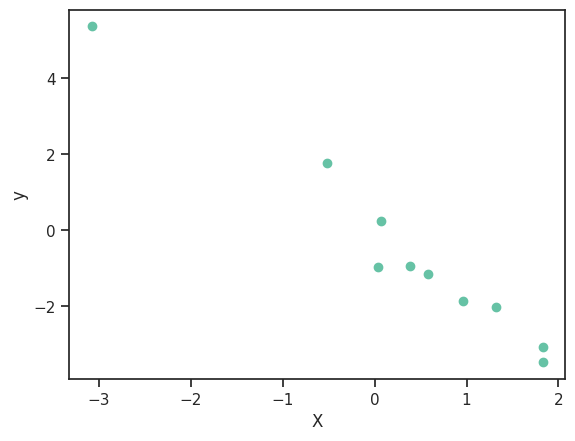

In [ ]:
# First we generate some data
# We generate n data points
n = 10
X = rng.standard_normal(10)

# The true y is generated as a linear function of X
beta = -1.8
y = np.dot(X,beta) + rng.standard_normal(n)*0.5

# We can plot the data to see what it looks like
plt.scatter(X,y)
plt.xlabel('X')
plt.ylabel('y')
plt.plot()

In [ ]:
# Let's fit a degree 6 polynomial
X_aug = np.zeros([n,7])
X_aug[:,0]=np.ones(n)
for i in range(6):
  X_aug[:,i+1] = X**(i+1)

# The solution is
beta_aug_hat = np.dot(np.linalg.inv(np.dot(X_aug.T,X_aug)),np.dot(X_aug.T,y))

In [ ]:
# let's see what the solution is that we computed
beta_aug_hat

array([-0.34583033, -1.2341353 ,  1.59799827, -5.64458478,  4.05604747,
        0.21327548, -0.5677991 ])

That means that our model says that the solution looks like:
$$
y = -0.346 - 1.23*x + 1.59*x^2 -5.64*x^3 + 4*x^4 + 0.21*x^5 -0.57*x^6
$$

[]

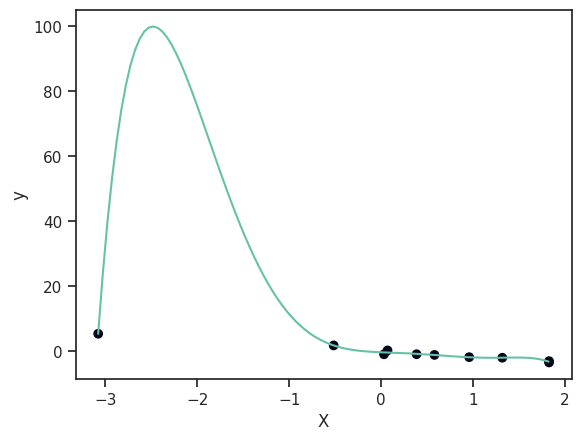

In [ ]:
# Now let's plot the fit
x_min = np.min(X)
x_max = np.max(X)
x_vals = np.arange(x_min,x_max,0.05)
N = x_vals.shape[0]
X_test = np.zeros([N,7])
X_test[:,0]=np.ones(N)
for i in range(6):
  X_test[:,i+1] = x_vals**(i+1)

y_test_hat = np.dot(X_test,beta_aug_hat)
plt.plot(x_vals,y_test_hat)
plt.scatter(X,y, c = np.ones(n))
plt.xlabel('X')
plt.ylabel('y')
plt.plot()

[]

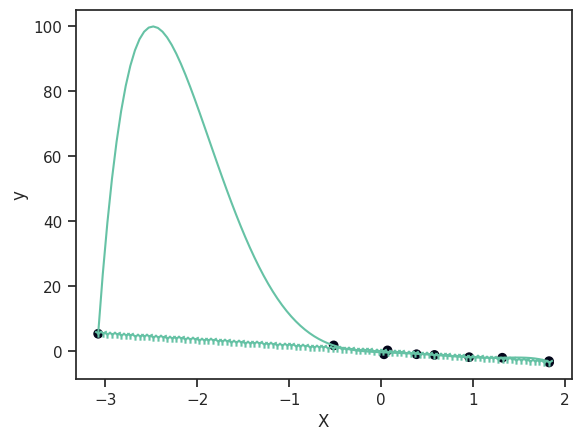

In [ ]:
# We can plot against some testing data
y_true = np.dot(x_vals,beta)
plt.plot(x_vals,y_test_hat)
plt.scatter(X,y, c = np.ones(n))
plt.scatter(x_vals,y_true, marker="1")
plt.xlabel('X')
plt.ylabel('y')
plt.plot()

# Adding L2 (Ridge) Regularization

Recall that for ridge, we minimize the training error plus a multiple of the sum of squared norms of $\beta$:
$$
\arg\min_{\beta}{\rm SSE}(\beta) + \lambda \sum \beta_i^2 = \arg\min_{\beta}{\rm SSE}(\beta) + \lambda \|\beta\|_2^2
$$

Similarly to ordinary least squares (OLS) regression, we can derive a closed form solution.

Recall first the OLS solution:
$$
\beta_{OLS} = (X^{\top}X)^{-1}X^{\top}y,
$$
and
$$
\beta_{RR}(\lambda) = (X^{\top}X + \lambda I)^{-1}X^{\top}y.
$$

[]

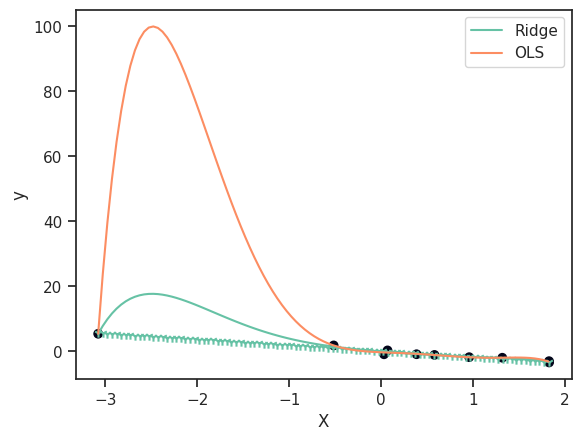

In [ ]:
# Set the value of the regularizer to lambda (note: misspelling necessary!)
lamda = 0.1

# We know the closed form
beta_RR_hat = np.dot(np.linalg.inv(np.dot(X_aug.T,X_aug) + lamda*np.eye(7)),np.dot(X_aug.T,y))

# We now plot
y_RR_hat = np.dot(X_test,beta_RR_hat)
plt.plot(x_vals,y_RR_hat,label='Ridge')
plt.plot(x_vals,y_test_hat, label='OLS')
plt.scatter(X,y, c = np.ones(n))
plt.scatter(x_vals,y_true, marker="1")
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.plot()

In [ ]:
beta_RR_hat

array([-0.09872637, -2.28417204,  0.80844862, -0.51369192,  0.42126394,
       -0.01679694, -0.07836996])

This is the solution from above, i.e., with no regularization:
$$
y = -0.346 - 1.23*x + 1.59*x^2 -5.64*x^3 + 4*x^4 + 0.21*x^5 -0.57*x^6
$$

## What is happening?

In this example, we have high variance because there are only 10 data points, and we are fitting a degree 6 polynomial, i.e., we have 7 degrees of freedom. This allows us to overfit. Regularization helps us from overfitting too much.

This example (with random seed 13) makes it seem like we should regularize as much as possible. This is not always the case. Eventually, the bias will be large enough that it will also hurt our solution quality.

# Colinearity in the Columns

Now we consider a different use: regularization to combat column colinearity.

When might we see colinear columns? If two columns are exactly colinear, this means that they are a multiple of each other. It is unlikely that we would see this in a data set. However, suppose that two columns are extremely good at predicting a 3rd column, via linear prediction. This means that the three columns are colinear. This could indeed happen inadvertently, as we follow the modern ethos of data analysis and collect as much data as we can and throw it to the code...

The following is a stylized example that illustrates what happens, and how this can lead to high variance, and how ridge regression can be used to aid in this problem.

In [ ]:
# We create an example with nearly colinear columns
# Suppose p = 5, n = 500 -- a good ratio
p = 5; n = 150
X = rng.standard_normal([n,p])
c = np.dot(X[:,0:p-1],[2,3,-1,0.5]) + rng.standard_normal([1,n])/1000;
# c is a column that is approximately a linear combination of
# columns 1, 2, 3 and 4. We set the 5th column of X equal to c
X[:,p-1] = c
beta = np.array([1,1,1,1,0])
#sigma = 0.3333
sigma = 0
y = np.dot(X,beta) + sigma*rng.standard_normal(n)

# Now let's also generate a test data set
n1 = 500 # number of testing points
X_test = rng.standard_normal([n1,p])
# In the test set, there's more noise in the 5th column
c_test = np.dot(X_test[:,0:p-1],[2,3,-1,0.5]) + rng.standard_normal([1,n1])/50;
X_test[:,p-1] = c_test
y_test = np.dot(X_test,beta) + sigma*rng.standard_normal(n1)

**Colinear columns would mean** that $X^{\top}X$ would not be invertible. Nearly colinear columns means that it's close to not being invertible, i.e., one of its eigenvalues is very close to zero. Let's check this.

### Recall:

$$
\hat{\beta} = (X^{\top}X)^{-1}X^{\top}y = \beta^{\ast} + (X^{\top}X)^{-1}X^{\top}e
$$

In [ ]:
# Note that the matrix Z = X'X has a very small eigenvalue.
Z = np.dot(X.T,X)
print('The ',p, 'eigenvalues are', np.linalg.eig(Z)[0])


The  5 eigenvalues are [2.29389172e+03 9.58357077e-06 1.39539591e+02 1.67530296e+02
 1.07383488e+02]


In [ ]:
# That means that its inverse has some very big eigenvalues.
# In fact, recall that the eigenvalues of the inverse matrix
# are always the inverse (one over) the eigenvalues of the original
# matrix.
print('The ',p, 'eigenvalues of the inverse are', np.linalg.eig(np.linalg.inv(Z))[0])


The  5 eigenvalues of the inverse are [1.04345242e+05 4.35940370e-04 5.96906963e-03 7.16642489e-03
 9.31241864e-03]


Recall that the formula for beta is
$$
\hat{\beta} = (X^{\top}X)^{-1} X^{\top}y.
$$
If we plug in: $y = X \beta^* + {\rm noise}$ (where $\beta^*$ is the true solution), we get
$$
\hat{\beta} = \beta^* + (X^{\top}X)^{-1} X^{\top}{\rm noise}
$$
Multiplying the noise by $(X^{\top}X)^{-1}$ has the potential to blow up the noise
and this is exactly what happens.

In [ ]:
# We form beta_hat

beta_hat = np.dot(np.dot(np.linalg.inv(Z),X.T),y.T)
print('This is beta_hat:', beta_hat)
print('Recall that the true beta is:', beta)

This is beta_hat: [1.00000000e+00 9.99999991e-01 1.00000000e+00 9.99999999e-01
 2.49448284e-09]
Recall that the true beta is: [1 1 1 1 0]


To see that this is indeed **"noise applification"** go up a few cells and set sigma = 0 (it's set to 0.333 in the original version of this notebook). When you do that, you are setting the additive error in "y = X \beta + Noise" to zero. Hence there is no noise to amplify. Hence there are no problems with the huge eigenvalues of (X'X)^-1, and we still recover the correct answer. But even a little bit of error, and this goes out the window.

In [ ]:
# Now let's compute the test error of OLS.
# You can see that it's not that good (it's big).
print('This is the testing error',np.linalg.norm(np.dot(X_test,beta_hat) - y_test))

This is the testing error 12.773629015887098


In [ ]:
# For comparison, the true error for the optimal beta is:
print('We can compare the above to the error of beta*:', np.linalg.norm(np.dot(X_test,beta) - y_test))

We can compare the above to the error of beta*: 7.582447570638022


## The ridge regression solution
Recall that the Ridge regression solution is:
$$ \hat{\beta}_{RR}(\lambda) = (X^{\top}X + \lambda I)^{-1}X^{\top}y $$

We first note that the eigenvalues of $(X^{\top}X + \lambda I)^{-1}$ are bounded away from zero: they're at least equal to $\lambda$.

In [ ]:
# Now we will add some regularization -- aka weight decay.
# Linear regression plus weight decay also has a closed form solution:
#
# beta_hat_R = (X'X + mu I)^-1 X'y -- compare to beta_hat = (X'X)^-1 X'y
# where I is the p by p identity matrix.
#
# Adding a small multiple of the identity to X'X barely changes the large eigenvalues,
# but it drastically changes the smallest eigenvalue -- it increases it to mu.
# Thus in the inverse, the largest eigenvalue will be at most 1/mu.
# Let's see this in action
#
lamda = .15
print(np.linalg.eig(Z)[0])
print(np.linalg.eig(Z + lamda*np.eye(p))[0])

[2.15434582e+03 8.91486627e-06 1.73913423e+02 1.28963037e+02
 1.35338939e+02]
[2.15449582e+03 1.50008915e-01 1.74063423e+02 1.29113037e+02
 1.35488939e+02]


In [ ]:
# Now we can form the solution to the ridge regression problem, using
# the closed-form formula from above
beta_hat_R = np.dot(np.dot(np.linalg.inv(Z + lamda*np.eye(p)),X.T),y.T)
print(beta_hat_R)

[0.40939352 0.12236593 1.31768016 0.84515106 0.31022349]


**Note that in the above**, the values are all much more controlled. There is no "error explosion" as in the OLS case. You may ask, however: why don't we recover the solution beta* = [1,1,1,1,0]?

In fact, we cannot. Think about a case where two columns (say, columns 1 and 2) are identical. Then there's nothing the data can do to differentiate between putting weight on column 1 or column 2 or somehow splitting it between the two. *Any of these options produces exactly the same prediction function*.

Now let's put it to the test, and check the test error of the ridge regression (regularized) solution.

In [ ]:
# Finally, let's compute the test error for the ridge regression solution.
print('The test error of the regularized solution is:', np.linalg.norm(np.dot(X_test,beta_hat_R) - y_test))

The test error of the regularized solution is: 7.695818577708316


In [ ]:
# Let's again see the original solution,
# the OLS solution (noise explosion), and the weight-decay version
# (aka ridge regression)
print(beta)
print(beta_hat)
print(beta_hat_R)

[1 1 1 1 0]
[-42.5340868  -64.29339469  22.79051772  -9.88853816  21.78174322]
[0.40939352 0.12236593 1.31768016 0.84515106 0.31022349]


In [ ]:
# And let's again print the test error for the original solution,
# the OLS solution (and hence the impact of noise explosion)
# and then the weight-decay (ridge regression) version.
#
# As you can see, the Ridge-Regression solution has test error
# far far closer to the error of the true solution, than
# the OLS solution does.

print("The test error for the true solution: ", np.linalg.norm(np.dot(X_test,beta) - y_test))
print("The test error for the OLS solution: ", np.linalg.norm(np.dot(X_test,beta_hat) - y_test))
print("The test error for the Ridge Regression solution: ", np.linalg.norm(np.dot(X_test,beta_hat_R) - y_test))

The test error for the true solution:  7.582447570638022
The test error for the OLS solution:  12.773629015887098
The test error for the Ridge Regression solution:  7.695818577708316


# Visualizing the Bias-Variance Tradeoff

We now consider a simple one dimensional regression example, and generating fresh data each time, we generate many samples from $\beta$ for different values of the regularization parameter.

Our goal is to plot the histogram of these.

We will see that the **center** of the histogram shifts towards zero as the regulariation coefficient grows. This means that the **bias** is growing. At the same time, the **standard deviation** shrinks. This means that the **variance** is decreasing.

Hence the **bias variance tradeoff**.

In [ ]:
# We set up the simple problem: y = x beta + noise
# where beta = 15
#
# We repeat the entire experiment M times
M = 10000
# the regularization coeff for ridge is mu
mu = 5
beta_OLS = np.zeros(M)
beta_R5 = np.zeros(M)
beta_R10 = np.zeros(M)
beta_R25 = np.zeros(M)
beta_R50 = np.zeros(M)
for i in np.arange(M):
        n = 30
        X = rng.standard_normal(n)
        beta = 15
        y = X*beta + rng.standard_normal(n)*20
        beta_OLS[i] = np.dot(X,y)/np.dot(X,X)
        beta_R5[i] = np.dot(X,y)/(np.dot(X,X)+5)
        beta_R10[i] = np.dot(X,y)/(np.dot(X,X)+10)
        beta_R25[i] = np.dot(X,y)/(np.dot(X,X)+25)
        beta_R50[i] = np.dot(X,y)/(np.dot(X,X)+50)

In [ ]:
print("The mean of the OLS solution is: ", np.mean(beta_OLS))
print("The mean of the Ridge5 solution is: ", np.mean(beta_R5))
print("The mean of the Ridge10 solution is: ", np.mean(beta_R10))
print("The mean of the Ridge25 solution is: ", np.mean(beta_R25))
print("The mean of the Ridge50 solution is: ", np.mean(beta_R50))

The mean of the OLS solution is:  14.994086964580987
The mean of the Ridge5 solution is:  12.756710776960904
The mean of the Ridge10 solution is:  11.122698948218092
The mean of the Ridge25 solution is:  8.06976583554401
The mean of the Ridge50 solution is:  5.559498260873117


In [ ]:
print("The standard deviation of the OLS solution is: ", np.std(beta_OLS))
print("The standard deviation of the Ridge5 solution is: ", np.std(beta_R5))
print("The standard deviation of the Ridge10 solution is: ", np.std(beta_R10))
print("The standard deviation of the Ridge25 solution is: ", np.std(beta_R25))
print("The standard deviation of the Ridge50 solution is: ", np.std(beta_R50))

The standard deviation of the OLS solution is:  3.752521397345754
The standard deviation of the Ridge5 solution is:  3.2066571894784315
The standard deviation of the Ridge10 solution is:  2.849458544057757
The standard deviation of the Ridge25 solution is:  2.201143811530409
The standard deviation of the Ridge50 solution is:  1.627400090049339


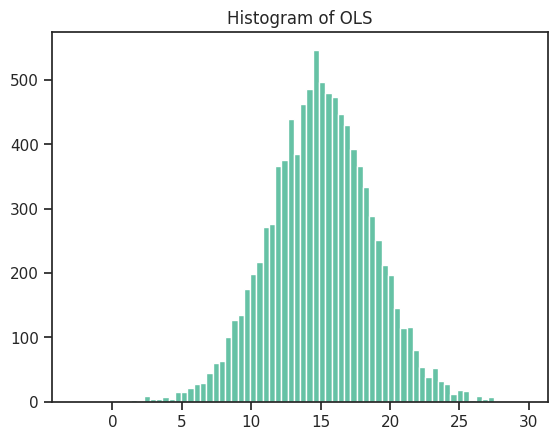

In [ ]:
a = np.hstack((rng.normal(size=1000),
               rng.normal(loc=5, scale=2, size=1000)))
_ = plt.hist(beta_OLS, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram of OLS")
plt.show()

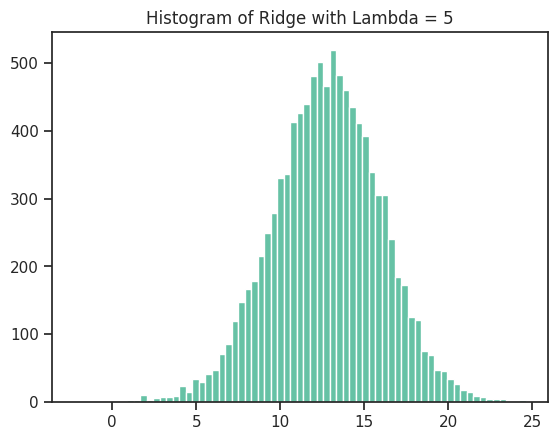

In [ ]:
a = np.hstack((rng.normal(size=1000),
               rng.normal(loc=5, scale=2, size=1000)))
_ = plt.hist(beta_R5, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram of Ridge with Lambda = 5")
plt.show()

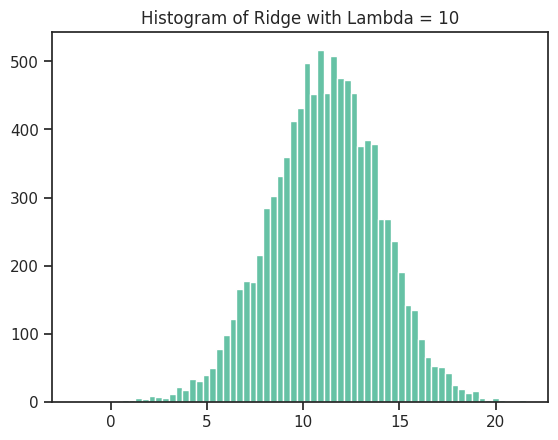

In [ ]:
a = np.hstack((rng.normal(size=1000),
               rng.normal(loc=5, scale=2, size=1000)))
_ = plt.hist(beta_R10, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram of Ridge with Lambda = 10")
plt.show()

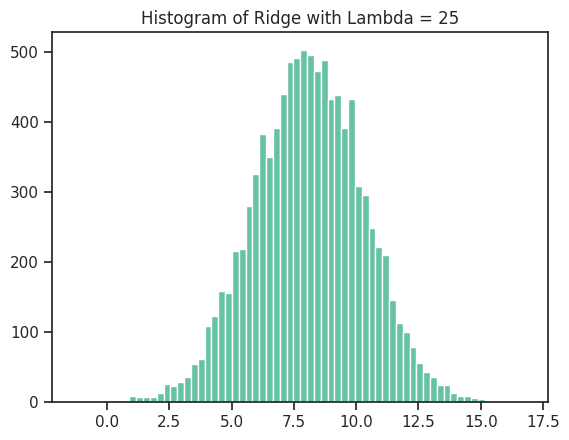

In [ ]:
a = np.hstack((rng.normal(size=1000),
               rng.normal(loc=5, scale=2, size=1000)))
_ = plt.hist(beta_R25, bins='auto')  # arguments are passed to np.histogram
plt.title("Histogram of Ridge with Lambda = 25")
plt.show()